# Simulation study analysis

This notebook implements the simulation study described in the dissertation. It compares classical logistic regression, a Bayesian hierarchical model (BHM), and causal forest across four heterogeneity scenarios:

1. No HTE
2. Joint subgroup
3. Published scenario
4. Continuous

In [1]:
from itertools import product
import logging
from time import perf_counter
import warnings

# Hide the missing widget warning from tqdm
warnings.filterwarnings("ignore", message="IProgress not found")

import arviz as az
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy.optimize import approx_fprime
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm
from tqdm.auto import tqdm

import config as cfg

# Hide routine PyMC sampling messages
logging.getLogger("pymc").setLevel(logging.ERROR)

## Simulation study settings

All random components derive from `RANDOM_SEED = 42` in `config.py`.
Independent random streams are created for calibration, evaluation, trial
generation, model fitting, BHM prior sensitivity analysis, and causal forest
hyperparameter tuning.

In [2]:
OUTPUT_DIRECTORY = cfg.RESULTS_DIRECTORY
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

FINAL_RUN = True
RUN_MAIN_ANALYSIS = False
RUN_PRIOR_SENSITIVITY = False
RUN_CAUSAL_FOREST_TUNING = False

if FINAL_RUN:
    N_REPLICATIONS = cfg.MONTE_CARLO_REPLICATIONS
else:
    N_REPLICATIONS = cfg.PILOT_REPLICATIONS

MCMC_DRAWS = 500
MCMC_WARMUP_DRAWS = 500
MCMC_CHAINS = 2
MINIMUM_BULK_ESS = 100

# Set BHM prior sensitivity specifications
PRIOR_SPECIFICATIONS = (
    {
        "label": "Mean-prior SD 1", "mean_prior_sd": 1.0,
        "heterogeneity_prior_scale": 1.0
    },
    {
        "label": "Primary", "mean_prior_sd": 2.0,
        "heterogeneity_prior_scale": 1.0
    },
    {
        "label": "Mean-prior SD 5", "mean_prior_sd": 5.0,
        "heterogeneity_prior_scale": 1.0
    },
    {
        "label": "Heterogeneity-prior scale 0.5", "mean_prior_sd": 2.0,
        "heterogeneity_prior_scale": 0.5
    },
    {
        "label": "Heterogeneity-prior scale 2", "mean_prior_sd": 2.0,
        "heterogeneity_prior_scale": 2.0
    }
)

## Simulation scenarios

Four prespecified scenarios are considered: No HTE, Joint subgroup, Published scenario, and Continuous. The placebo model, calibration process, and scenario-specific treatment probabilities are defined in `config.py` and described in detail in the dissertation.

For evaluation, the true CATE is the risk difference between the semaglutide and placebo response probabilities. Subgroup differences compare mean CATEs between the prespecified groups for each scenario.

In [3]:
def normal_interval(estimate, standard_error):
    """Return a normal 95% interval in a small dictionary"""
    estimate = float(estimate)
    standard_error = float(standard_error)

    # Use a normal approximation
    return {
        "estimate": estimate,
        "standard_error": standard_error,
        "lower": estimate - 1.96 * standard_error,
        "upper": estimate + 1.96 * standard_error
    }

def posterior_interval(draws):
    """Summarise draws by posterior mean, SD, and 95% quantile interval"""
    draws = np.asarray(draws, dtype=float).reshape(-1)
    # Calculate the 2.5% and 97.5% quantiles
    lower, upper = np.quantile(draws, [0.025, 0.975])

    return {
        # Use the posterior mean as the point estimate
        "estimate": float(draws.mean()),
        # Store posterior SD under the shared standard_error key for compatibility
        "standard_error": float(draws.std(ddof=1)),
        "lower": float(lower),
        "upper": float(upper)
    }

def subgroup_difference(cate, groups):
    """Compare the mean CATE in group one with the mean in group zero"""
    # Compare the two group averages
    group_one_effect = cate[groups["group_one"]].mean()
    group_zero_effect = cate[groups["group_zero"]].mean()
    return float(group_one_effect - group_zero_effect)

def define_evaluation_subgroups(data, scenario):
    """Define subgroups using the fixed evaluation population"""
    if scenario != "continuous":
        return cfg.define_subgroups(data, scenario)
    lower, upper = CONTINUOUS_AGE_QUARTILES
    age = data["age_years"].to_numpy()
    return {
        "label": "upper minus lower age quartile",
        "group_one": age >= upper,
        "group_zero": age <= lower
    }

def validate_saved_results(data, required_columns, analysis_name):
    """Check that saved results match the current simulation design"""
    missing_columns = sorted(set(required_columns) - set(data.columns))
    if missing_columns:
        raise ValueError(
            f"Saved results for {analysis_name} are missing required columns "
            f"{missing_columns}. Rerun {analysis_name}."
        )
    saved_scenarios = set(data["scenario"].dropna())
    current_scenarios = set(cfg.PRIMARY_ANALYSIS_SCENARIOS)
    if saved_scenarios != current_scenarios:
        raise ValueError(
            f"Saved results for {analysis_name} use scenarios "
            f"{sorted(saved_scenarios)}, "
            f"not the current scenarios {sorted(current_scenarios)}. "
            f"Rerun {analysis_name}."
        )

MODEL_FACTOR_COLUMNS = ["female", "age_65", "bmi_35_to_40", "bmi_40", "prediabetes"]

def prepare_analysis_data(data):
    """Add model factors from the subgroup labels created in config.py"""
    prepared = data.copy()
    prepared["age_65"] = prepared["age_group"].eq("65 or older").astype(int)
    prepared["bmi_35_to_40"] = prepared["bmi_group"].eq("35 to under 40").astype(int)
    prepared["bmi_40"] = prepared["bmi_group"].eq("40 or higher").astype(int)
    return prepared

def calculate_truth(evaluation_data, scenario):
    """Calculate the known truth for one scenario"""
    # Use hidden probabilities only for evaluation
    placebo_probability, treated_probability = cfg.calculate_outcome_probabilities(
        evaluation_data, scenario
    )
    true_cate = treated_probability - placebo_probability
    groups = define_evaluation_subgroups(evaluation_data, scenario)

    return {
        "cate": true_cate,
        "subgroup_difference": subgroup_difference(true_cate, groups)
    }

## Method 1. Classical logistic regression

The classical model includes treatment, five prespecified subgroup indicators, and their treatment-by-subgroup interactions. It is fitted using binomial logistic regression with HC0 robust covariance estimates.

In [4]:
def make_classical_design(data, treatment):
    """Create the columns used in the classical logistic regression"""
    # Use one treatment value for every row when needed
    if np.isscalar(treatment):
        treated = np.repeat(treatment, len(data))
    else:
        treated = np.asarray(treatment)

    subgroup_design = data[MODEL_FACTOR_COLUMNS]
    main_design = pd.DataFrame({"intercept": 1.0, "treated": treated}, index=data.index)
    interactions = subgroup_design.mul(treated, axis=0).add_prefix("treated_x_")
    return pd.concat([main_design, subgroup_design, interactions], axis=1)

def predict_classical_cate(coefficients, evaluation_data):
    """Predict each person's risk under treatment and placebo"""
    # Predict the same people under both arms
    treated_design = make_classical_design(evaluation_data, treatment=1)
    placebo_design = make_classical_design(evaluation_data, treatment=0)

    treated_risk = cfg.inverse_logit(treated_design @ coefficients)
    placebo_risk = cfg.inverse_logit(placebo_design @ coefficients)

    return treated_risk - placebo_risk

The subgroup-difference standard error is obtained using the delta method,
with the gradient evaluated numerically using `approx_fprime`.

In [5]:
def fit_classical_model(data, evaluation_data, scenario):
    """Fit the classical model and return the results"""
    # Create the design matrix for the classical logistic regression
    observed_design = make_classical_design(data, treatment=data["treated"].to_numpy())

    # Fit logistic regression with heteroskedasticity-robust standard errors
    fitted_model = sm.GLM(
        data["weight_loss_5pct"], observed_design, family=sm.families.Binomial()
    ).fit(cov_type="HC0", maxiter=100)

    coefficients = fitted_model.params.to_numpy()
    covariance = fitted_model.cov_params().to_numpy()
    groups = define_evaluation_subgroups(evaluation_data, scenario)

    # Estimate individual and subgroup effects
    cate = predict_classical_cate(coefficients, evaluation_data)
    point_estimate = subgroup_difference(cate, groups)

    # Recalculate the subgroup difference after small coefficient changes
    def recalculate_difference(changed_coefficients):
        changed_cate = predict_classical_cate(changed_coefficients, evaluation_data)
        return subgroup_difference(changed_cate, groups)

    # Approximate the delta method gradient
    gradient = approx_fprime(coefficients, recalculate_difference, epsilon=1e-6)
    variance = gradient @ covariance @ gradient
    standard_error = np.sqrt(max(float(variance), 0))

    return {
        "method": "classical_interaction",
        "subgroup_difference_result": normal_interval(point_estimate, standard_error),
        "cate": cate,
        "converged": bool(fitted_model.converged),
        "diagnostic": ""
    }

## Method 2. Bayesian hierarchical model

The BHM uses 24 mutually exclusive strata formed from sex, age group, BMI group, and glycaemic status. Stratum-specific response probabilities are estimated separately by treatment arm with partial pooling.

The primary specification uses a Normal(0, 2²) prior for the arm-specific mean log odds and a HalfNormal(1) prior for the arm-specific between-stratum standard deviation. The model is fitted using the non-centred parameterisation implemented below.

In [6]:
N_STRATA = 24

def find_stratum(data):
    """Assign every participant to one of the 24 strata"""
    indicators = data[MODEL_FACTOR_COLUMNS]
    bmi_group = indicators["bmi_35_to_40"] + 2 * indicators["bmi_40"]

    # Give each factor combination one index
    stratum = (
        indicators["female"] * 12
        + indicators["age_65"] * 6
        + bmi_group * 2
        + indicators["prediabetes"]
    )
    return stratum.to_numpy(dtype=int)

def count_stratum_outcomes(data):
    """Count participants and responses by arm and stratum"""
    stratum = find_stratum(data)
    treated = data["treated"].to_numpy(dtype=int)
    outcome = data["weight_loss_5pct"].to_numpy(dtype=int)

    # Store placebo in row 0 and treatment in row 1
    totals = np.zeros((2, N_STRATA), dtype=int)
    responses = np.zeros((2, N_STRATA), dtype=int)

    # Count participants and responses
    for arm in [0, 1]:
        in_arm = treated == arm
        totals[arm] = np.bincount(stratum[in_arm], minlength=N_STRATA)
        responses[arm] = np.bincount(
            stratum[in_arm], weights=outcome[in_arm], minlength=N_STRATA
        ).astype(int)

    return totals, responses

In [7]:
def fit_bayesian_model(
    data, evaluation_data, scenario, fit_seed, mean_prior_sd=2.0,
    heterogeneity_prior_scale=1.0
):
    """Fit the Bayesian hierarchical model"""
    totals, responses = count_stratum_outcomes(data)

    with pm.Model() as model:
        # Set arm-level priors
        global_log_odds = pm.Normal(
            "global_log_odds", mu=0, sigma=mean_prior_sd, shape=2
        )
        heterogeneity = pm.HalfNormal(
            "heterogeneity", sigma=heterogeneity_prior_scale, shape=2
        )
        # Set partially pooled stratum effects
        stratum_z = pm.Normal("stratum_z", mu=0, sigma=1, shape=(2, N_STRATA))
        # Calculate stratum-specific log odds
        log_odds = global_log_odds[:, None] + heterogeneity[:, None] * stratum_z
        # Convert log odds to probabilities
        probability = pm.Deterministic("probability", pm.math.sigmoid(log_odds))

        # Use aggregated binomial observations
        pm.Binomial("responses", n=totals, p=probability, observed=responses)

        # Draw from the posterior
        posterior = pm.sample(
            draws=MCMC_DRAWS,
            tune=MCMC_WARMUP_DRAWS,
            chains=MCMC_CHAINS,
            cores=1,
            target_accept=0.95,
            random_seed=fit_seed,
            progressbar=False,
            compute_convergence_checks=False
        )

    # Extract the probability draws
    probability_draws = np.asarray(posterior.posterior["probability"], dtype=float)
    # Assign evaluation participants to strata
    evaluation_stratum = find_stratum(evaluation_data)

    # Convert arm probabilities into CATE draws
    cate_draws = (
        probability_draws[:, :, 1, evaluation_stratum]
        - probability_draws[:, :, 0, evaluation_stratum]
    )

    # Calculate the subgroup difference for every draw
    groups = define_evaluation_subgroups(evaluation_data, scenario)
    subgroup_difference_draws = cate_draws[:, :, groups["group_one"]].mean(
        axis=2
    ) - cate_draws[:, :, groups["group_zero"]].mean(axis=2)

    # Calculate diagnostics for model parameters
    model_diagnostics = az.summary(
        posterior, var_names=["global_log_odds", "heterogeneity", "probability"]
    )
    # Check the maximum R-hat, which should be close to one
    max_rhat = float(model_diagnostics["r_hat"].max())
    # Check minimum bulk effective sample size (the larger the better)
    minimum_bulk_ess = float(model_diagnostics["ess_bulk"].min())

    # Check the primary subgroup estimate
    subgroup_rhat = float(np.asarray(az.rhat(subgroup_difference_draws)))
    subgroup_ess = float(
        np.asarray(az.ess(subgroup_difference_draws, method="bulk"))
    )
    # Combine the diagnostics results
    max_rhat = max(max_rhat, subgroup_rhat)
    minimum_bulk_ess = min(minimum_bulk_ess, subgroup_ess)

    # Check for divergences (ideally zero)
    divergences = int(posterior.sample_stats["diverging"].sum())

    # Mark the model as converged only when every diagnostic passes
    converged = (
        max_rhat < 1.05 and minimum_bulk_ess >= MINIMUM_BULK_ESS and divergences == 0
    )

    # Calculate the posterior mean CATE
    cate = cate_draws.mean(axis=(0, 1))

    return {
        "method": "bayesian_hierarchical",
        "subgroup_difference_result": posterior_interval(
            subgroup_difference_draws
        ),
        "cate": cate,
        "converged": converged,
        "diagnostic": (
            f"mean prior SD={mean_prior_sd:g}, "
            f"heterogeneity prior scale={heterogeneity_prior_scale:g}, "
            f"max R-hat={max_rhat:.3f}, "
            f"minimum bulk ESS={minimum_bulk_ess:.0f}, "
            f"divergences={divergences}"
        )
    }

## Method 3. Causal forest

The causal forest is fitted using EconML with continuous age, sex, continuous BMI, and prediabetes as baseline covariates. The fitted model predicts CATEs in the fixed evaluation population.

In [8]:
def get_baseline_features(data):
    """Return the baseline variables used by the causal forest"""
    return data[cfg.BASELINE_COLUMNS].to_numpy(dtype=float)

def population_standard_error(effect_inference):
    """Get the standard error of a population mean effect"""
    summary = effect_inference.population_summary(alpha=0.05)
    return float(np.asarray(summary.stderr_mean).squeeze())

# Final settings selected by causal forest hyperparameter tuning
CAUSAL_FOREST_SETTINGS = {
    "min_samples_leaf": 20,
    "max_samples": 0.45,
    "max_depth": 5
}

CAUSAL_FOREST_TUNING_REPLICATIONS = 30

# Candidate settings used for causal forest hyperparameter tuning
CAUSAL_FOREST_TUNING_GRID = {
    "min_samples_leaf": (5, 10, 20),
    "max_samples": (0.45, 0.50),
    "max_depth": (None, 5)
}

def fit_causal_forest(
    data, evaluation_data, scenario, fit_seed, forest_settings=None
):
    """Fit the causal forest and return the required results"""
    settings = CAUSAL_FOREST_SETTINGS if forest_settings is None else forest_settings

    # Define the nuisance and forest models
    forest = CausalForestDML(
        model_y=RandomForestClassifier(
            n_estimators=100,
            min_samples_leaf=10,
            max_features="sqrt",
            random_state=fit_seed,
            n_jobs=1
        ),
        model_t=DummyClassifier(strategy="prior"),
        discrete_outcome=True,
        discrete_treatment=True,
        cv=3,
        n_estimators=400,
        min_samples_leaf=settings["min_samples_leaf"],
        max_samples=settings["max_samples"],
        criterion="mse",
        max_depth=settings["max_depth"],
        honest=True,
        inference=True,
        random_state=fit_seed,
        n_jobs=1
    )

    # Fit the simulated trial
    forest.fit(
        data["weight_loss_5pct"].to_numpy(dtype=int),
        data["treated"].to_numpy(dtype=int),
        X=get_baseline_features(data),
        inference="auto"
    )

    # Predict CATEs in the evaluation population
    evaluation_features = get_baseline_features(evaluation_data)
    cate = np.asarray(forest.effect(evaluation_features), dtype=float).reshape(-1)

    # Estimate the prespecified subgroup difference
    groups = define_evaluation_subgroups(evaluation_data, scenario)
    point_estimate = subgroup_difference(cate, groups)

    group_one_inference = forest.effect_inference(
        evaluation_features[groups["group_one"]]
    )
    group_zero_inference = forest.effect_inference(
        evaluation_features[groups["group_zero"]]
    )

    # Combine the two subgroup standard errors
    standard_error = np.sqrt(
        population_standard_error(group_one_inference) ** 2
        + population_standard_error(group_zero_inference) ** 2
    )

    return {
        "method": "causal_forest",
        "subgroup_difference_result": normal_interval(
            point_estimate, standard_error
        ),
        "cate": cate,
        "converged": True,
        "diagnostic": "Approximate interval with subgroup covariance omitted"
    }

## Fixed evaluation population

Each fitted method predicts CATEs for the same independently generated
population of 1,000 people. This population is held fixed across simulation
replications and is used only to evaluate model performance. Models are fitted
using separate simulated trial data. The Continuous scenario uses age quartiles
calculated once in this population. Its middle 50% remains in CATE RMSE but is
excluded from the subgroup difference.

In [9]:
METHODS = {
    "classical_interaction": fit_classical_model,
    "bayesian_hierarchical": fit_bayesian_model,
    "causal_forest": fit_causal_forest
}

# Create one fixed evaluation population
evaluation_random_generator = cfg.create_random_generators()["evaluation"]
evaluation_population = prepare_analysis_data(
    cfg.simulate_baseline(cfg.EVALUATION_N, evaluation_random_generator)
)
CONTINUOUS_AGE_QUARTILES = tuple(
    np.quantile(evaluation_population["age_years"], [0.25, 0.75])
)

# Save the true values for each scenario
scenario_truth = {}
for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
    scenario_truth[scenario] = calculate_truth(evaluation_population, scenario)

## True CATE patterns

The figure shows the true arm risks and CATE distributions in the fixed
evaluation population before any Monte Carlo model fitting.

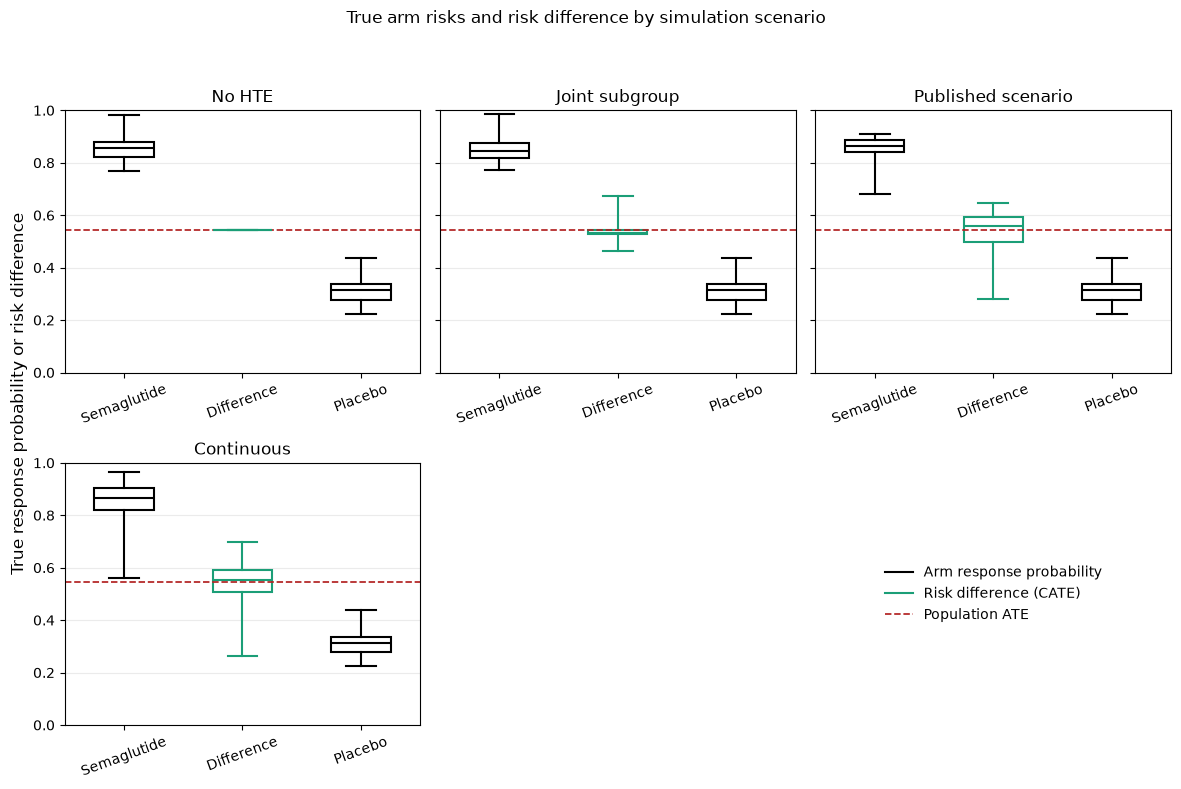

In [10]:
def plot_true_arm_and_difference_boxplots(evaluation_data, path, title=None):
    """Plot both true arm risks and their difference for every scenario"""
    figure, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True)
    difference_color = "#1B9E77"

    for axis, scenario in zip(axes.flat, cfg.PRIMARY_ANALYSIS_SCENARIOS):
        placebo_risk, semaglutide_risk = cfg.calculate_outcome_probabilities(
            evaluation_data, scenario
        )
        risk_difference = semaglutide_risk - placebo_risk
        boxplot = axis.boxplot(
            [semaglutide_risk, risk_difference, placebo_risk],
            positions=[1, 2, 3],
            widths=0.5,
            whis=(0, 100),
            showfliers=False,
            patch_artist=True,
            medianprops={"color": "black", "linewidth": 1.5},
            boxprops={"edgecolor": "black", "linewidth": 1.5},
            whiskerprops={"color": "black", "linewidth": 1.5},
            capprops={"color": "black", "linewidth": 1.5}
        )

        for box in boxplot["boxes"]:
            box.set_facecolor("white")

        # Highlight the risk-difference distribution
        boxplot["boxes"][1].set_edgecolor(difference_color)
        boxplot["medians"][1].set_color(difference_color)
        for line in boxplot["whiskers"][2:4] + boxplot["caps"][2:4]:
            line.set_color(difference_color)

        axis.axhline(
            cfg.ATE_TARGET, color="#B22222", linestyle="--", linewidth=1.25
        )
        axis.set_title(cfg.SCENARIO_LABELS[scenario])
        axis.set_xticks(
            [1, 2, 3], ["Semaglutide", "Difference", "Placebo"], rotation=20
        )
        axis.set_ylim(0, 1)
        axis.grid(axis="y", alpha=0.25)

    axes.flat[-2].axis("off")
    legend_axis = axes.flat[-1]
    legend_axis.axis("off")
    legend_axis.plot(
        [], [], color="black", linewidth=1.5, label="Arm response probability"
    )
    legend_axis.plot(
        [], [], color=difference_color, linewidth=1.5, label="Risk difference (CATE)"
    )
    legend_axis.plot(
        [], [], color="#B22222", linestyle="--", linewidth=1.25,
        label="Population ATE"
    )
    legend_axis.legend(loc="center", frameon=False)
    figure.supylabel("True response probability or risk difference")
    if title is not None:
        figure.suptitle(title)
    top = 0.94 if title is not None else 1
    figure.tight_layout(rect=(0, 0, 1, top))
    figure.savefig(path, dpi=180, bbox_inches="tight")
    return figure

true_cate_figure = plot_true_arm_and_difference_boxplots(
    evaluation_population,
    OUTPUT_DIRECTORY / "true_cate_scenarios.png",
    title="True arm risks and risk difference by simulation scenario"
)
truth_no_title_path = OUTPUT_DIRECTORY / "true_cate_scenarios_no_title.png"
truth_figure_no_title = plot_true_arm_and_difference_boxplots(
    evaluation_population, truth_no_title_path
)
plt.close(truth_figure_no_title)

## Simulation setup

The simulation saves one row for every scenario, replication, and method.
Failed fits are kept in the results rather than silently removed.

In [11]:
def make_successful_row(fitted, truth, scenario, replication):
    """Convert a successful model fit into one table row"""
    # Calculate errors against the known truth
    subgroup_difference_result = fitted["subgroup_difference_result"]
    estimation_error = (
        subgroup_difference_result["estimate"] - truth["subgroup_difference"]
    )
    cate_mse = np.mean((fitted["cate"] - truth["cate"]) ** 2)

    return {
        "scenario": scenario,
        "replication": replication,
        "method": fitted["method"],
        "success": True,
        "converged": fitted["converged"],
        "diagnostic": fitted["diagnostic"],
        "error": "",
        "subgroup_difference_truth": truth["subgroup_difference"],
        "subgroup_difference_estimate": subgroup_difference_result["estimate"],
        "subgroup_difference_standard_error": subgroup_difference_result[
            "standard_error"
        ],
        "subgroup_difference_lower": subgroup_difference_result["lower"],
        "subgroup_difference_upper": subgroup_difference_result["upper"],
        "subgroup_difference_error": estimation_error,
        "subgroup_difference_covered": (
            subgroup_difference_result["lower"]
            <= truth["subgroup_difference"]
            <= subgroup_difference_result["upper"]
        ),
        "cate_mse": cate_mse
    }

def make_failed_row(method, scenario, replication, exception):
    """Store a failed fit using the same identifying columns"""
    return {
        "scenario": scenario,
        "replication": replication,
        "method": method,
        "success": False,
        "converged": False,
        "diagnostic": "",
        "error": f"{type(exception).__name__}: {exception}"
    }

def simulate_one_trial(random_generator, scenario):
    """Generate one trial and return the columns available to an analyst"""
    baseline = cfg.simulate_baseline(cfg.TOTAL_N, random_generator)
    trial, _ = cfg.simulate_trial(baseline, random_generator, scenario=scenario)
    # Prepare the shared subgroup factors for the classical and Bayesian methods
    factor_labels = ["age_group", "bmi_group"]
    return prepare_analysis_data(trial[[*cfg.ANALYSIS_COLUMNS, *factor_labels]])

## Run the main simulation

Within each replication, all three methods are fitted to the same simulated trial.
This creates a paired comparison at the trial level. The final analysis contains
6,000 model fits across 500 replications per scenario.
A pilot with 10 replications per scenario contains 120 model fits.

In [12]:
def run_main_simulation(replications):
    """Run every method for every scenario and replication"""
    random_generators = cfg.create_random_generators()
    trial_random_generator = random_generators["main_trials"]
    model_random_generator = random_generators["main_models"]
    rows = []
    total_fits = len(cfg.PRIMARY_ANALYSIS_SCENARIOS) * replications * len(METHODS)
    progress = tqdm(
        total=total_fits, desc="Main simulation", unit="fit", dynamic_ncols=True
    )

    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for replication in range(1, replications + 1):
            # Generate one trial shared by all methods
            analysis_data = simulate_one_trial(trial_random_generator, scenario)

            for method_name, fit_method in METHODS.items():
                progress.set_postfix_str(
                    f"{cfg.SCENARIO_LABELS[scenario]} | "
                    f"replication {replication}/{replications} | "
                    f"{cfg.METHOD_LABELS[method_name]}"
                )
                try:
                    if method_name == "classical_interaction":
                        fitted = fit_method(
                            analysis_data, evaluation_population, scenario
                        )
                    else:
                        # Give each stochastic fit its own reproducible seed
                        fit_seed = int(model_random_generator.integers(0, 2**32))
                        fitted = fit_method(
                            analysis_data, evaluation_population, scenario, fit_seed
                        )
                    row = make_successful_row(
                        fitted, scenario_truth[scenario], scenario, replication
                    )
                except Exception as exception:
                    # Keep failed fits in the output
                    row = make_failed_row(method_name, scenario, replication, exception)

                rows.append(row)
                progress.update(1)

        progress.write(
            f"Completed {cfg.SCENARIO_LABELS[scenario]} "
            f"({replications} replications)"
        )

    progress.close()

    results = pd.DataFrame(rows)
    results.to_csv(OUTPUT_DIRECTORY / "replication_results.csv", index=False)
    return results

## Summarise the simulation

Accuracy measures use only successful fits that passed the convergence
checks. Failure and non-convergence rates use all attempted fits.

In [13]:
def root_mean_square(values):
    """Calculate the root mean square of a set of values"""
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan
    return np.sqrt(np.mean(values**2))

def binomial_mcse(rate, number_of_replications):
    """Calculate Monte Carlo standard error for a proportion"""
    if number_of_replications == 0:
        return np.nan
    return np.sqrt(rate * (1 - rate) / number_of_replications)

def summarise_subset(subset):
    """Summarise one set of attempted model fits"""
    # Use successful converged fits
    successful = subset["success"].fillna(False).astype(bool)
    converged = subset["converged"].fillna(False).astype(bool)
    usable = subset[successful & converged]

    summary = {
        "attempted_replications": len(subset),
        "usable_replications": len(usable),
        "failure_rate": float((~successful).mean()),
        "nonconvergence_rate": float((successful & ~converged).mean()),
        "subgroup_difference_truth": np.nan,
        "subgroup_difference_bias": np.nan,
        "subgroup_difference_rmse": np.nan,
        "subgroup_difference_coverage": np.nan,
        "subgroup_difference_coverage_mcse": np.nan,
        "cate_rmse": np.nan
    }

    if len(usable) == 0:
        return summary

    coverage = usable["subgroup_difference_covered"].mean()
    summary["subgroup_difference_truth"] = usable["subgroup_difference_truth"].iloc[0]
    summary["subgroup_difference_bias"] = usable["subgroup_difference_error"].mean()
    summary["subgroup_difference_rmse"] = root_mean_square(
        usable["subgroup_difference_error"]
    )
    summary["subgroup_difference_coverage"] = coverage
    summary["subgroup_difference_coverage_mcse"] = binomial_mcse(coverage, len(usable))
    summary["cate_rmse"] = np.sqrt(usable["cate_mse"].mean())

    return summary

def summarise_main_results(results):
    """Create one summary row for each scenario and method"""
    rows = []

    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for method in METHODS:
            subset = results[
                (results["scenario"] == scenario) & (results["method"] == method)
            ]
            row = summarise_subset(subset)
            row["scenario"] = scenario
            row["method"] = method
            row["scenario_label"] = cfg.SCENARIO_LABELS[scenario]
            row["method_label"] = cfg.METHOD_LABELS[method]
            rows.append(row)

    summary = pd.DataFrame(rows)
    summary.to_csv(OUTPUT_DIRECTORY / "summary.csv", index=False)
    return summary

In [14]:
def plot_comparison(summary, path, title=None):
    """Plot the three headline measures by method and scenario"""
    panels = [
        ("cate_rmse", "CATE RMSE"),
        ("subgroup_difference_rmse", "Subgroup difference RMSE"),
        ("subgroup_difference_coverage", "95% subgroup difference coverage")
    ]
    scenarios = list(cfg.PRIMARY_ANALYSIS_SCENARIOS)
    methods = list(cfg.METHOD_LABELS)
    x_positions = np.arange(len(scenarios))
    method_offsets = np.linspace(-0.16, 0.16, len(methods))
    method_markers = ["o", "s", "^"]
    method_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    figure, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Draw one point for each method and scenario
    for method, offset, marker, color in zip(
        methods, method_offsets, method_markers, method_colors
    ):
        method_summary = summary[summary["method"] == method].set_index("scenario")
        method_summary = method_summary.reindex(scenarios)

        for axis, panel in zip(axes.flat, panels):
            column, panel_title = panel
            axis.scatter(
                x_positions + offset,
                method_summary[column],
                color=color,
                marker=marker,
                s=65,
                label=cfg.METHOD_LABELS[method],
                zorder=3
            )
            axis.set_title(panel_title)
            axis.set_xticks(
                x_positions,
                [cfg.SCENARIO_LABELS[s] for s in scenarios],
                rotation=25,
                ha="right"
            )
            axis.grid(alpha=0.25)

    # Add the nominal coverage line
    axes.flat[2].axhline(0.95, color="black", linestyle="--")
    axes.flat[2].set_ylim(-0.03, 1.03)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    figure.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
    if title is not None:
        figure.suptitle(title)
    top = 0.96 if title is not None else 1
    figure.tight_layout(rect=(0, 0.09, 1, top))
    figure.savefig(path, dpi=180, bbox_inches="tight")
    return figure

## Causal forest hyperparameter tuning

This separate tuning experiment uses independently generated trials rather than the final 500 replications. Twelve candidate specifications are evaluated using 30 replications per scenario. The primary selection criterion is the equally weighted mean CATE RMSE across the four scenarios.

In [15]:
TUNING_RESULTS_PATH = OUTPUT_DIRECTORY / "causal_forest_tuning_results.csv"

# Create the 12 candidate combinations in a fixed order
tuning_candidates = []
grid = product(
    CAUSAL_FOREST_TUNING_GRID["min_samples_leaf"],
    CAUSAL_FOREST_TUNING_GRID["max_samples"],
    CAUSAL_FOREST_TUNING_GRID["max_depth"]
)
for candidate_number, values in enumerate(grid, start=1):
    min_samples_leaf, max_samples, max_depth = values
    tuning_candidates.append(
        {
            "candidate_id": f"cf_{candidate_number:02d}",
            "min_samples_leaf": min_samples_leaf,
            "max_samples": max_samples,
            "max_depth": max_depth
        }
    )

def run_causal_forest_tuning(replications):
    """Run all candidates in the causal forest hyperparameter tuning"""
    # Separate streams preserve main analysis randomness
    random_generators = cfg.create_random_generators()
    trial_random_generator = random_generators["tuning_trials"]
    model_random_generator = random_generators["tuning_models"]
    rows = []
    total_fits = (
        len(cfg.PRIMARY_ANALYSIS_SCENARIOS) * replications * len(tuning_candidates)
    )
    progress = tqdm(
        total=total_fits,
        desc="Causal forest hyperparameter tuning",
        unit="fit",
        dynamic_ncols=True
    )

    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for replication in range(1, replications + 1):
            # All candidates share a newly simulated trial for paired comparison
            analysis_data = simulate_one_trial(trial_random_generator, scenario)
            # A common seed also keeps the unchanged nuisance model paired
            fit_seed = int(model_random_generator.integers(0, 2**32))
            progress.set_postfix_str(
                f"{cfg.SCENARIO_LABELS[scenario]} | "
                f"replication {replication}/{replications}"
            )

            for candidate in tuning_candidates:
                settings = {
                    "min_samples_leaf": candidate["min_samples_leaf"],
                    "max_samples": candidate["max_samples"],
                    "max_depth": candidate["max_depth"]
                }
                start_time = perf_counter()

                try:
                    fitted = fit_causal_forest(
                        analysis_data,
                        evaluation_population,
                        scenario,
                        fit_seed,
                        forest_settings=settings
                    )
                    row = make_successful_row(
                        fitted, scenario_truth[scenario], scenario, replication
                    )
                except Exception as exception:
                    row = make_failed_row(
                        "causal_forest", scenario, replication, exception
                    )

                row.update(candidate)
                row["fit_seed"] = fit_seed
                row["runtime_seconds"] = perf_counter() - start_time
                rows.append(row)
                progress.update(1)
    progress.close()
    results = pd.DataFrame(rows)
    results.to_csv(TUNING_RESULTS_PATH, index=False)
    return results

In [16]:
# Run the causal forest hyperparameter tuning or load saved detailed results
if RUN_CAUSAL_FOREST_TUNING:
    tuning_results = run_causal_forest_tuning(
        replications=CAUSAL_FOREST_TUNING_REPLICATIONS
    )
elif TUNING_RESULTS_PATH.exists():
    tuning_results = pd.read_csv(TUNING_RESULTS_PATH)
    tuning_required_columns = {
        "scenario", "candidate_id", "min_samples_leaf", "max_samples",
        "max_depth", "cate_mse", "runtime_seconds"
    }
    validate_saved_results(
        tuning_results, tuning_required_columns,
        "causal forest hyperparameter tuning"
    )
    candidates_per_scenario = tuning_results.groupby("scenario")[
        "candidate_id"
    ].nunique()
    if not candidates_per_scenario.eq(len(tuning_candidates)).all():
        raise ValueError(
            "Saved causal forest hyperparameter tuning results do not contain "
            "all 12 current candidates for every scenario. Rerun the "
            "causal forest hyperparameter tuning."
        )
else:
    tuning_results = None
    print(
        "Causal forest hyperparameter tuning is disabled and no saved "
        "results were found."
    )

In [17]:
if tuning_results is not None:
    tuning_columns = [
        "candidate_id", "min_samples_leaf", "max_samples", "max_depth"
    ]

    # Calculate CATE RMSE within each scenario
    tuning_scenario_summary = (
        tuning_results.groupby(
            [*tuning_columns, "scenario"], as_index=False, dropna=False
        )
        .agg(
            cate_rmse=("cate_mse", lambda values: np.sqrt(values.mean())),
            runtime_seconds=("runtime_seconds", "sum")
        )
    )

    # Average equally across the four scenarios
    tuning_summary = (
        tuning_scenario_summary.groupby(
            tuning_columns, as_index=False, dropna=False
        )
        .agg(
            average_cate_rmse=(
                "cate_rmse", lambda values: values.mean(skipna=False)
            ),
            total_runtime_seconds=("runtime_seconds", "sum")
        )
        .sort_values("average_cate_rmse", na_position="last")
    )
    best_candidate = tuning_summary.dropna(
        subset=["average_cate_rmse"]
    ).iloc[0]

    display(tuning_scenario_summary.round(6))
    display(tuning_summary.round(6))
else:
    tuning_scenario_summary = None
    tuning_summary = None
    best_candidate = None

best_candidate

,candidate_id,min_samples_leaf,max_samples,max_depth,scenario,cate_rmse,runtime_seconds
0,cf_01,5,0.45,NaN,continuous,0.101836,16.309821
1,cf_01,5,0.45,NaN,joint_subgroup,0.106412,16.857522
2,cf_01,5,0.45,NaN,no_hte,0.106136,17.796387
3,cf_01,5,0.45,NaN,published_scenario,0.108322,16.985763
4,cf_02,5,0.45,5.0,continuous,0.074355,14.566952
5,cf_02,5,0.45,5.0,joint_subgroup,0.076532,15.019346
6,cf_02,5,0.45,5.0,no_hte,0.077443,15.811517
7,cf_02,5,0.45,5.0,published_scenario,0.084142,14.940385
8,cf_03,5,0.50,NaN,continuous,0.105504,17.118592
9,cf_03,5,0.50,NaN,joint_subgroup,0.110703,17.618174


,candidate_id,min_samples_leaf,max_samples,max_depth,average_cate_rmse,total_runtime_seconds
9,cf_10,20,0.45,5.0,0.069373,56.260108
11,cf_12,20,0.50,5.0,0.070010,58.140411
8,cf_09,20,0.45,NaN,0.071329,56.796335
10,cf_11,20,0.50,NaN,0.073012,59.101716
5,cf_06,10,0.45,5.0,0.074232,58.492405
7,cf_08,10,0.50,5.0,0.074878,60.722745
1,cf_02,5,0.45,5.0,0.078118,60.338200
3,cf_04,5,0.50,5.0,0.078356,62.238879
4,cf_05,10,0.45,NaN,0.086345,62.458883
6,cf_07,10,0.50,NaN,0.089608,65.243017


candidate_id                 cf_10
min_samples_leaf                20
max_samples                   0.45
max_depth                      5.0
average_cate_rmse         0.069373
total_runtime_seconds    56.260108
Name: 9, dtype: object

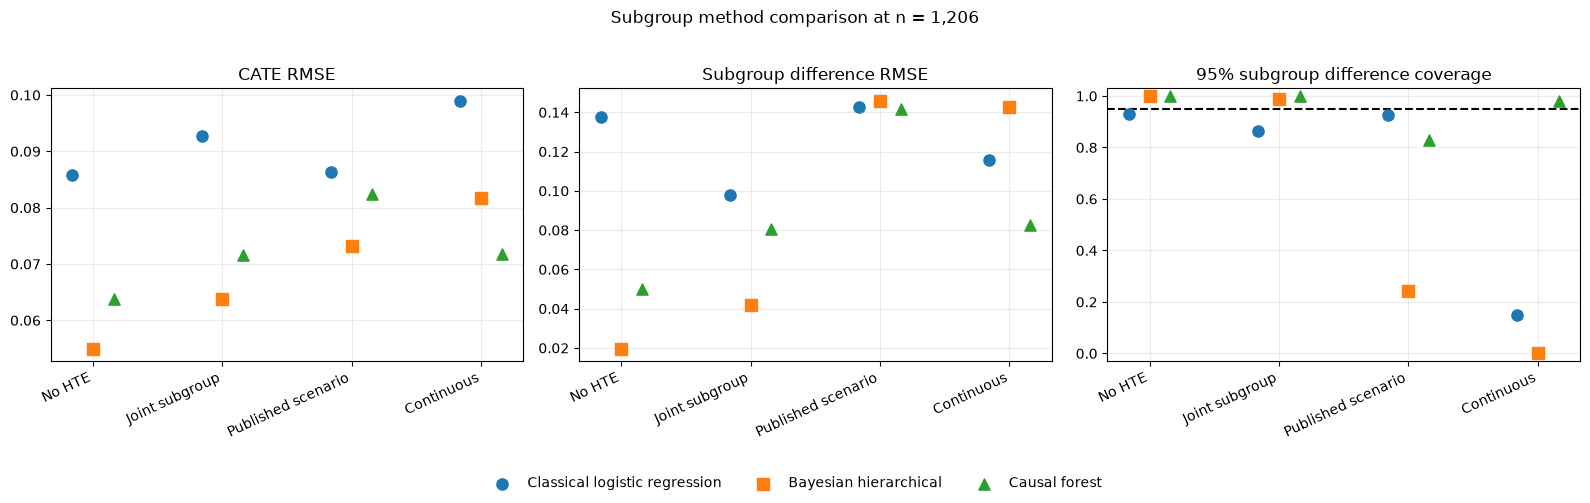

In [18]:
if RUN_MAIN_ANALYSIS:
    replication_results = run_main_simulation(replications=N_REPLICATIONS)
    comparison_summary = summarise_main_results(replication_results)
else:
    replication_results = pd.read_csv(OUTPUT_DIRECTORY / "replication_results.csv")
    main_result_columns = {
        "scenario", "method", "success", "converged", "cate_mse",
        "subgroup_difference_error", "subgroup_difference_covered"
    }
    validate_saved_results(
        replication_results, main_result_columns, "main simulation results"
    )
    comparison_summary = pd.read_csv(OUTPUT_DIRECTORY / "summary.csv")
    main_summary_columns = {
        "scenario", "method", "cate_rmse", "subgroup_difference_rmse",
        "subgroup_difference_coverage"
    }
    validate_saved_results(
        comparison_summary, main_summary_columns, "main simulation summary"
    )

comparison_figure = plot_comparison(
    comparison_summary,
    OUTPUT_DIRECTORY / "model_comparison.png",
    title=f"Subgroup method comparison at n = {cfg.TOTAL_N:,}"
)

## BHM prior sensitivity analysis

This separate sensitivity analysis varies one prior component at a time around the primary BHM specification. Five unique prior specifications are evaluated using 10 independently generated trial datasets per scenario.

In [19]:
def run_prior_sensitivity(replications):
    """Repeat Bayesian fitting under each prespecified prior specification"""
    random_generators = cfg.create_random_generators()
    trial_random_generator = random_generators["prior_trials"]
    model_random_generator = random_generators["prior_models"]
    rows = []
    total_fits = (
        len(cfg.PRIMARY_ANALYSIS_SCENARIOS) * replications * len(PRIOR_SPECIFICATIONS)
    )
    progress = tqdm(
        total=total_fits, desc="BHM prior sensitivity analysis", unit="fit",
        dynamic_ncols=True
    )

    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for replication in range(1, replications + 1):
            # Reuse one trial across prior specifications
            analysis_data = simulate_one_trial(trial_random_generator, scenario)

            # Fit one model for each prior specification
            for prior_specification in PRIOR_SPECIFICATIONS:
                prior_label = prior_specification["label"]
                mean_prior_sd = prior_specification["mean_prior_sd"]
                heterogeneity_prior_scale = prior_specification[
                    "heterogeneity_prior_scale"
                ]
                progress.set_postfix_str(
                    f"{cfg.SCENARIO_LABELS[scenario]} | "
                    f"replication {replication}/{replications} | "
                    f"{prior_label}"
                )
                fit_seed = int(model_random_generator.integers(0, 2**32))

                try:
                    fitted = fit_bayesian_model(
                        analysis_data,
                        evaluation_population,
                        scenario,
                        fit_seed,
                        mean_prior_sd=mean_prior_sd,
                        heterogeneity_prior_scale=heterogeneity_prior_scale
                    )
                    row = make_successful_row(
                        fitted, scenario_truth[scenario], scenario, replication
                    )
                except Exception as exception:
                    row = make_failed_row(
                        "bayesian_hierarchical", scenario, replication, exception
                    )

                row["prior_label"] = prior_label
                row["mean_prior_sd"] = mean_prior_sd
                row["heterogeneity_prior_scale"] = heterogeneity_prior_scale
                rows.append(row)
                progress.update(1)

        progress.write(
            f"BHM prior sensitivity analysis completed "
            f"{cfg.SCENARIO_LABELS[scenario]} "
            f"({replications} replications)"
        )

    progress.close()

    results = pd.DataFrame(rows)
    results.to_csv(OUTPUT_DIRECTORY / "prior_sensitivity_results.csv", index=False)
    return results

def summarise_prior_results(results):
    """Create one summary row for each scenario and prior specification"""
    rows = []

    # Summarise each scenario and prior specification
    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for prior_specification in PRIOR_SPECIFICATIONS:
            prior_label = prior_specification["label"]
            mean_prior_sd = prior_specification["mean_prior_sd"]
            heterogeneity_prior_scale = prior_specification[
                "heterogeneity_prior_scale"
            ]
            subset = results[
                (results["scenario"] == scenario)
                & (results["prior_label"] == prior_label)
            ]
            row = summarise_subset(subset)
            row["scenario"] = scenario
            row["prior_label"] = prior_label
            row["mean_prior_sd"] = mean_prior_sd
            row["heterogeneity_prior_scale"] = heterogeneity_prior_scale
            row["scenario_label"] = cfg.SCENARIO_LABELS[scenario]
            rows.append(row)

    summary = pd.DataFrame(rows)
    summary.to_csv(OUTPUT_DIRECTORY / "prior_sensitivity_summary.csv", index=False)
    return summary

In [20]:
if RUN_PRIOR_SENSITIVITY:
    prior_sensitivity_results = run_prior_sensitivity(
        replications=cfg.PRIOR_SENSITIVITY_REPLICATIONS
    )
    prior_sensitivity_summary = summarise_prior_results(
        prior_sensitivity_results
    )
else:
    prior_sensitivity_results = pd.read_csv(
        OUTPUT_DIRECTORY / "prior_sensitivity_results.csv"
    )
    prior_result_columns = {
        "scenario", "prior_label", "mean_prior_sd",
        "heterogeneity_prior_scale", "cate_mse",
        "subgroup_difference_error", "subgroup_difference_covered"
    }
    validate_saved_results(
        prior_sensitivity_results, prior_result_columns,
        "BHM prior sensitivity analysis results"
    )
    prior_sensitivity_summary = pd.read_csv(
        OUTPUT_DIRECTORY / "prior_sensitivity_summary.csv"
    )
    prior_summary_columns = {
        "scenario", "prior_label", "mean_prior_sd",
        "heterogeneity_prior_scale", "cate_rmse",
        "subgroup_difference_rmse", "subgroup_difference_coverage"
    }
    validate_saved_results(
        prior_sensitivity_summary, prior_summary_columns,
        "BHM prior sensitivity analysis summary"
    )

prior_sensitivity_summary[
    [
        "scenario_label",
        "prior_label",
        "mean_prior_sd",
        "heterogeneity_prior_scale",
        "usable_replications",
        "cate_rmse",
        "subgroup_difference_rmse",
        "subgroup_difference_coverage",
        "nonconvergence_rate"
    ]
].round(3)

,scenario_label,prior_label,mean_prior_sd,heterogeneity_prior_scale,usable_replications,cate_rmse,subgroup_difference_rmse,subgroup_difference_coverage,nonconvergence_rate
0,No HTE,Mean-prior SD 1,1.0,1.0,10,0.059,0.036,1.000,0.0
1,No HTE,Primary,2.0,1.0,10,0.060,0.037,1.000,0.0
2,No HTE,Mean-prior SD 5,5.0,1.0,10,0.060,0.039,1.000,0.0
3,No HTE,Heterogeneity-prior scale 0.5,2.0,0.5,10,0.053,0.024,1.000,0.0
4,No HTE,Heterogeneity-prior scale 2,2.0,2.0,10,0.063,0.045,1.000,0.0
5,Joint subgroup,Mean-prior SD 1,1.0,1.0,10,0.064,0.024,1.000,0.0
6,Joint subgroup,Primary,2.0,1.0,10,0.063,0.023,1.000,0.0
7,Joint subgroup,Mean-prior SD 5,5.0,1.0,10,0.063,0.022,1.000,0.0
8,Joint subgroup,Heterogeneity-prior scale 0.5,2.0,0.5,10,0.059,0.024,1.000,0.0
9,Joint subgroup,Heterogeneity-prior scale 2,2.0,2.0,10,0.065,0.025,1.000,0.0


## Main simulation results

The first table counts failed and non-converged fits. The second shows the
reason for every unusable fit. The final table contains the performance
measures used in the study comparison.

In [21]:
# Count fit outcomes
diagnostics = pd.Series(
    {
        "attempted_fits": len(replication_results),
        "successful_fits": int(replication_results["success"].sum()),
        "failed_fits": int((~replication_results["success"]).sum()),
        "nonconverged_fits": int(
            (
                replication_results["success"]
                & ~replication_results["converged"].fillna(False)
            ).sum()
        )
    },
    name="value"
)
diagnostics

attempted_fits       6000
successful_fits      6000
failed_fits             0
nonconverged_fits      20
Name: value, dtype: int64

In [22]:
# Find failed or non-converged fits
successful = replication_results["success"]
converged = replication_results["converged"].fillna(False)
unusable = ~successful | ~converged

replication_results.loc[
    unusable, ["scenario", "replication", "method", "diagnostic", "error"]
]

,scenario,replication,method,diagnostic,error
556,no_hte,186,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",NaN
589,no_hte,197,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",NaN
649,no_hte,217,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",NaN
799,no_hte,267,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",NaN
871,no_hte,291,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",NaN
973,no_hte,325,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",NaN
1150,no_hte,384,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",NaN
1861,joint_subgroup,121,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",NaN
2164,joint_subgroup,222,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",NaN
2764,joint_subgroup,422,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",NaN


In [23]:
result_columns = [
    "scenario_label",
    "method_label",
    "cate_rmse",
    "subgroup_difference_rmse",
    "subgroup_difference_coverage"
]

comparison_summary[result_columns].round(3)

,scenario_label,method_label,cate_rmse,subgroup_difference_rmse,subgroup_difference_coverage
0,No HTE,Classical interaction,0.086,0.137,0.930
1,No HTE,Bayesian hierarchical,0.055,0.020,1.000
2,No HTE,Causal forest,0.064,0.050,1.000
3,Joint subgroup,Classical interaction,0.093,0.098,0.864
4,Joint subgroup,Bayesian hierarchical,0.064,0.042,0.990
5,Joint subgroup,Causal forest,0.072,0.080,1.000
6,Published scenario,Classical interaction,0.086,0.142,0.928
7,Published scenario,Bayesian hierarchical,0.073,0.146,0.241
8,Published scenario,Causal forest,0.082,0.142,0.830
9,Continuous,Classical interaction,0.099,0.116,0.150


In [24]:
comparison_no_title_path = OUTPUT_DIRECTORY / "model_comparison_no_title.png"
comparison_figure_no_title = plot_comparison(
    comparison_summary, comparison_no_title_path
)
plt.close(comparison_figure_no_title)